# Feature Engineering: Polynomials, Interactions, and Splines

**Flow:** a curved signal → why a straight line underfits → polynomial and spline features → interactions → choosing complexity with cross-validation → one held-out score.

Linear models are linear **in their coefficients**, not necessarily in the raw inputs. By transforming features (powers, products, spline bases) we can fit curved relationships while keeping the fast, well-understood linear machinery. The risk is overfitting: more flexible feature maps can memorize noise. We control that with a validation split and cross-validation, and we report a single held-out score at the end.


## 1. Setup and versions
We import only the pinned stack and print versions for reproducibility. A single colorblind-safe palette (Okabe-Ito) is reused for all categorical series.

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Colorblind-safe Okabe-Ito categorical palette used throughout this curriculum.
OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold, validation_curve
from sklearn.metrics import mean_squared_error, r2_score

rng = np.random.default_rng(7)


## 2. Deterministic synthetic data and split BEFORE fitting
The true signal is a smooth non-linear curve. We generate it deterministically, then split into train/test **before** any fitting or feature construction. The test rows are untouched until the final evaluation.

Train samples: 112   Test samples: 48


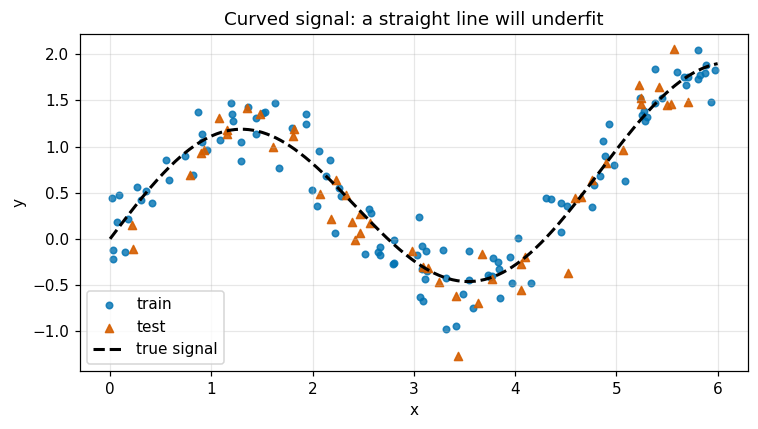

In [3]:
# True signal: a smooth non-linear function of a single input.
def true_signal(x):
    return np.sin(1.3 * x) + 0.15 * x

n = 160
x = np.sort(rng.uniform(0, 6, size=n))
y = true_signal(x) + rng.normal(0, 0.25, size=n)
X = x[:, None]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=0
)
print(f'Train samples: {X_train.shape[0]}   Test samples: {X_test.shape[0]}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train[:, 0], y_train, s=18, color=OKABE_ITO[0], label='train', alpha=0.8)
ax.scatter(X_test[:, 0], y_test, s=28, color=OKABE_ITO[3], marker='^', label='test', alpha=0.9)
grid = np.linspace(0, 6, 400)
ax.plot(grid, true_signal(grid), color=OKABE_ITO[7], lw=2, ls='--', label='true signal')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Curved signal: a straight line will underfit')
ax.legend()
plt.tight_layout(); plt.show()


## 3. A straight line underfits
Fitting plain OLS on the raw feature gives a poor fit because the relationship is curved. We show the fit and its held-out error to establish a baseline.

Linear baseline test R^2 : 0.010
Linear baseline test RMSE: 0.771


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


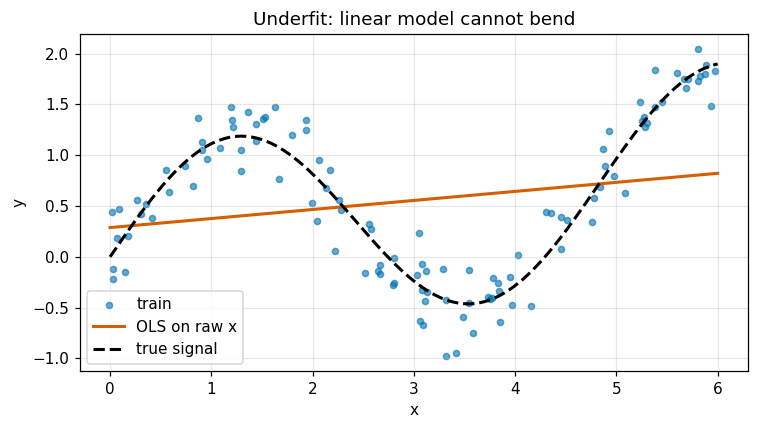

In [4]:
lin = LinearRegression().fit(X_train, y_train)
pred_line = lin.predict(X_test)
print(f'Linear baseline test R^2 : {r2_score(y_test, pred_line):.3f}')
print(f'Linear baseline test RMSE: {mean_squared_error(y_test, pred_line, squared=False):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_train[:, 0], y_train, s=16, color=OKABE_ITO[0], alpha=0.6, label='train')
ax.plot(grid, lin.predict(grid[:, None]), color=OKABE_ITO[3], lw=2, label='OLS on raw x')
ax.plot(grid, true_signal(grid), color=OKABE_ITO[7], lw=2, ls='--', label='true signal')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Underfit: linear model cannot bend')
ax.legend(); plt.tight_layout(); plt.show()


## 4. Polynomial features and the under/overfit spectrum
`PolynomialFeatures(degree=d)` expands `x` into `1, x, x^2, ..., x^d`. Low degree underfits; very high degree overfits (wiggles that chase noise). We visualize several degrees fit **on the training set only** and compare against the true signal.

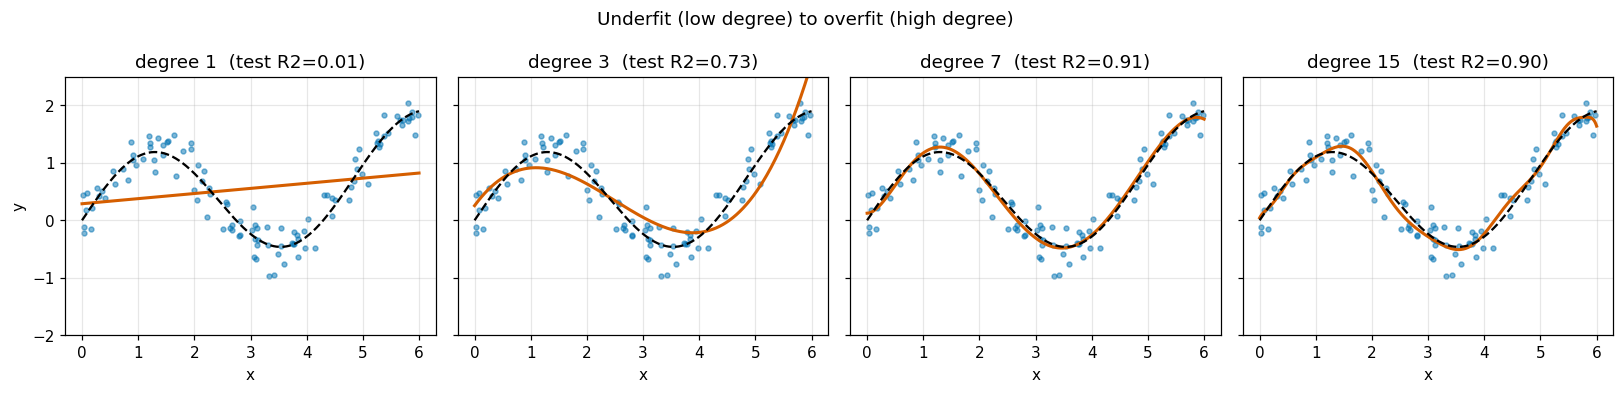

In [5]:
degrees = [1, 3, 7, 15]
fig, axes = plt.subplots(1, len(degrees), figsize=(15, 3.6), sharey=True)
for ax, d in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(d, include_bias=False),
                          StandardScaler(), LinearRegression())
    model.fit(X_train, y_train)
    ax.scatter(X_train[:, 0], y_train, s=10, color=OKABE_ITO[0], alpha=0.5)
    ax.plot(grid, model.predict(grid[:, None]), color=OKABE_ITO[3], lw=2, label=f'deg {d}')
    ax.plot(grid, true_signal(grid), color=OKABE_ITO[7], lw=1.5, ls='--')
    ax.set_ylim(-2.0, 2.5)
    ax.set_title(f'degree {d}  (test R2={r2_score(y_test, model.predict(X_test)):.2f})')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
fig.suptitle('Underfit (low degree) to overfit (high degree)')
plt.tight_layout(); plt.show()


## 5. Choose complexity with cross-validation, not the test set
We must not pick the degree by peeking at the test set. Instead we run k-fold cross-validation on the **training data** and select the degree with the best mean CV score. The chart shows train vs. validation error diverging as complexity grows: the classic overfitting signature.

Best degree by CV: 10  (mean CV RMSE=0.248)


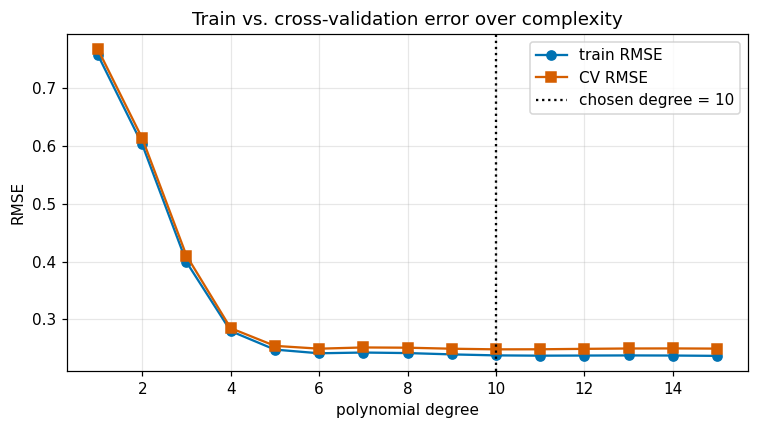

In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)
deg_range = np.arange(1, 16)
pipe = make_pipeline(PolynomialFeatures(include_bias=False), StandardScaler(), Ridge(alpha=1e-3))
train_scores, val_scores = validation_curve(
    pipe, X_train, y_train,
    param_name='polynomialfeatures__degree', param_range=deg_range,
    cv=cv, scoring='neg_root_mean_squared_error')
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)
best_deg = int(deg_range[np.argmin(val_rmse)])
print(f'Best degree by CV: {best_deg}  (mean CV RMSE={val_rmse.min():.3f})')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(deg_range, train_rmse, marker='o', color=OKABE_ITO[0], label='train RMSE')
ax.plot(deg_range, val_rmse, marker='s', color=OKABE_ITO[3], label='CV RMSE')
ax.axvline(best_deg, color=OKABE_ITO[7], ls=':', label=f'chosen degree = {best_deg}')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('RMSE')
ax.set_title('Train vs. cross-validation error over complexity')
ax.legend(); plt.tight_layout(); plt.show()


## 6. Splines: local flexibility without global blow-up
High-degree global polynomials swing wildly near the edges (Runge phenomenon). **B-splines** (`SplineTransformer`) use piecewise-polynomial basis functions with local support, so adding flexibility does not destabilize the whole curve. We visualize the spline basis and compare a spline fit to a high-degree polynomial.

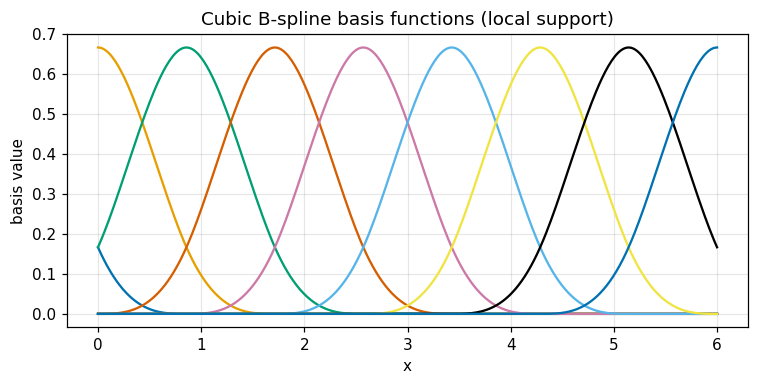

In [7]:
spline = SplineTransformer(n_knots=8, degree=3, include_bias=False)
basis = spline.fit_transform(grid[:, None])
fig, ax = plt.subplots(figsize=(7, 3.6))
for j in range(basis.shape[1]):
    ax.plot(grid, basis[:, j], color=OKABE_ITO[j % len(OKABE_ITO)], lw=1.5)
ax.set_xlabel('x'); ax.set_ylabel('basis value')
ax.set_title('Cubic B-spline basis functions (local support)')
plt.tight_layout(); plt.show()


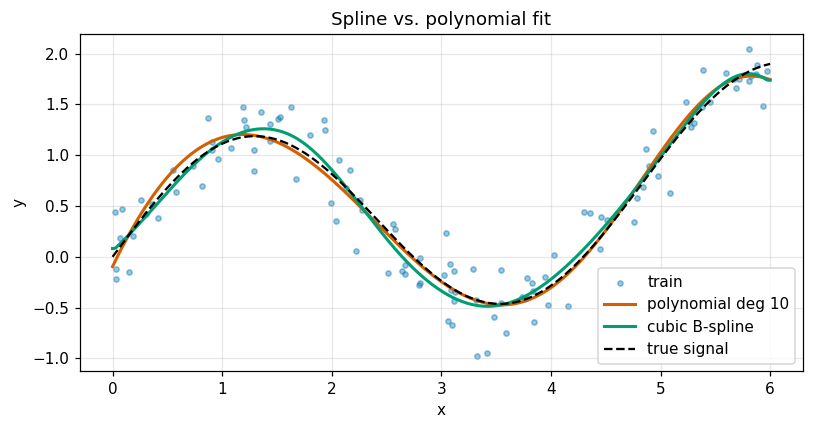

In [8]:
poly_model = make_pipeline(PolynomialFeatures(best_deg, include_bias=False),
                           StandardScaler(), Ridge(alpha=1e-3)).fit(X_train, y_train)
spline_model = make_pipeline(SplineTransformer(n_knots=8, degree=3, include_bias=False),
                             Ridge(alpha=1e-3)).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.scatter(X_train[:, 0], y_train, s=12, color=OKABE_ITO[0], alpha=0.4, label='train')
ax.plot(grid, poly_model.predict(grid[:, None]), color=OKABE_ITO[3], lw=2, label=f'polynomial deg {best_deg}')
ax.plot(grid, spline_model.predict(grid[:, None]), color=OKABE_ITO[2], lw=2, label='cubic B-spline')
ax.plot(grid, true_signal(grid), color=OKABE_ITO[7], lw=1.5, ls='--', label='true signal')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Spline vs. polynomial fit')
ax.legend(); plt.tight_layout(); plt.show()


## 7. Interactions between features
With more than one input, `PolynomialFeatures(interaction_only=True)` adds product terms like `x1 * x2`. Interactions let the effect of one feature depend on another. We build a small two-feature dataset whose target genuinely depends on the product, and show that adding the interaction term recovers the signal.

In [9]:
m = 300
x1 = rng.uniform(-2, 2, size=m)
x2 = rng.uniform(-2, 2, size=m)
# Target needs the interaction term x1*x2 to be modeled well.
y2 = 0.5 * x1 - 0.4 * x2 + 1.5 * (x1 * x2) + rng.normal(0, 0.3, size=m)
X2 = np.column_stack([x1, x2])
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.3, random_state=2)

no_int = make_pipeline(StandardScaler(), LinearRegression()).fit(X2_tr, y2_tr)
with_int = make_pipeline(PolynomialFeatures(2, interaction_only=True, include_bias=False),
                         StandardScaler(), LinearRegression()).fit(X2_tr, y2_tr)
print(f'No interaction   test R^2: {r2_score(y2_te, no_int.predict(X2_te)):.3f}')
print(f'With interaction test R^2: {r2_score(y2_te, with_int.predict(X2_te)):.3f}')


No interaction   test R^2: 0.072
With interaction test R^2: 0.979


## 8. Final held-out evaluation
We commit to the CV-selected polynomial degree and the spline model, refit on the full training set, and score **once** on the held-out test data. This is the only time the test set is used for scoring the regression models.

In [10]:
final_poly = make_pipeline(PolynomialFeatures(best_deg, include_bias=False),
                           StandardScaler(), Ridge(alpha=1e-3)).fit(X_train, y_train)
final_spline = make_pipeline(SplineTransformer(n_knots=8, degree=3, include_bias=False),
                             Ridge(alpha=1e-3)).fit(X_train, y_train)

for name, mdl in [('linear (raw x)', lin), (f'polynomial deg {best_deg}', final_poly),
                  ('cubic B-spline', final_spline)]:
    p = mdl.predict(X_test)
    print(f'{name:22s}  test R^2={r2_score(y_test, p):.3f}  test RMSE={mean_squared_error(y_test, p, squared=False):.3f}')


linear (raw x)          test R^2=0.010  test RMSE=0.771
polynomial deg 10       test R^2=0.900  test RMSE=0.246
cubic B-spline          test R^2=0.903  test RMSE=0.242


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Key takeaways and caveats

- Linear models can fit curves by transforming inputs (powers, splines) or adding interaction terms; they stay linear in the coefficients.
- **Degree/knots control the bias-variance trade-off.** Too little flexibility underfits; too much overfits. Choose it with cross-validation on training data, never by looking at the test set.
- **Splines are usually safer than high-degree global polynomials** because their basis functions have local support and do not blow up at the boundaries.
- **Interactions matter** when a feature's effect depends on another feature. Add them deliberately; they grow the feature count quickly.
- Always put the transformer and estimator in a `Pipeline` so scaling/expansion is fit on training folds only (no leakage). Report a single held-out score at the end.
